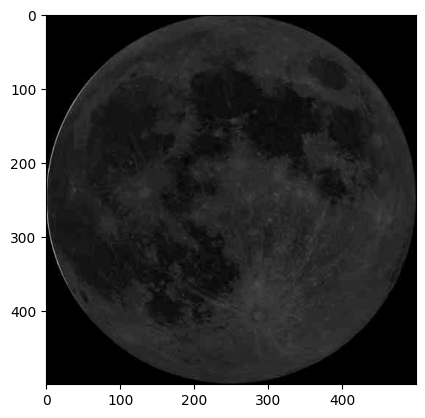

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

original_img = Image.open("original_image.png").convert("L")
plt.imshow(original_img, cmap='gray')

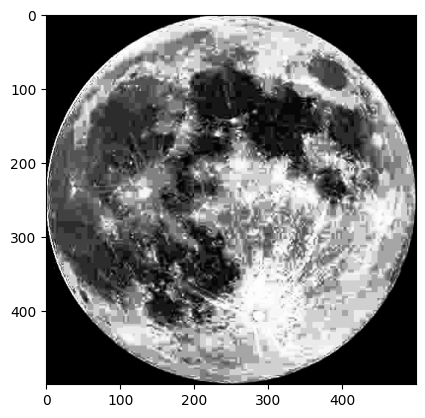

In [38]:
def histogram_equalization(img):
    img = np.array(img)
    hist = np.zeros(256)
    for pixel in img.flatten():
        hist[pixel] += 1

    pdf = hist / img.size
    cdf = np.cumsum(pdf)
    mapping = np.floor(255 * cdf).astype(np.uint8)
    equalized_img = mapping[img]

    return equalized_img

he_image = histogram_equalization(original_img)
plt.imshow(he_image, cmap='gray')

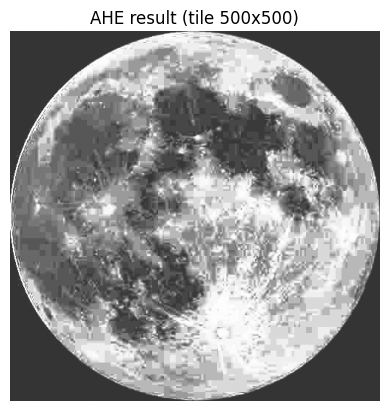

In [46]:
def ahe(img, tile_size):
    img = np.array(img)
    h, w = img.shape
    output = np.zeros_like(img)
    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):
            tile = img[y:y+tile_size, x:x+tile_size]
            n = tile.shape[0] * tile.shape[1]
            if n == 0:
                continue
            hist = np.zeros(256)
            for px in tile.flatten():
                hist[px] += 1
            cdf = np.cumsum(hist / n)
            output[y:y+tile_size, x:x+tile_size] = np.floor(255 * cdf).astype(np.uint8)[tile]
    return output
 
 
def run_ahe_progression(img):
    img = np.array(img)
    h, w = img.shape
 
    ts, sizes = 4, []
    while ts <= min(h, w):
        sizes.append(ts)
        ts *= 2
    if sizes[-1] != min(h, w):
        sizes.append(min(h, w))
 
    result = None
    for ts in sizes:
        result = ahe(img, ts)
 
    plt.imshow(result, cmap='gray', vmin=0, vmax=255)
    plt.title(f'AHE result (tile {sizes[-1]}x{sizes[-1]})')
    plt.axis('off')
    plt.show()
 
    return result

ahe_image = run_ahe_progression(original_img)

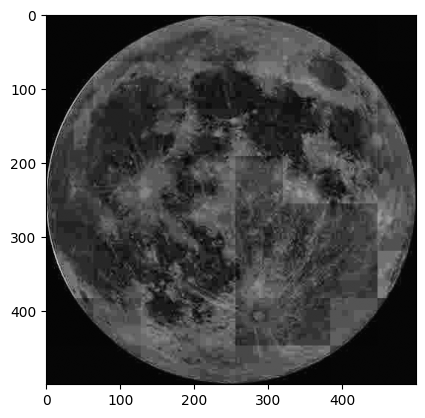

In [47]:
def clahe(img, tile_size=64, clip_limit=40.0):
    img = np.array(img)
    h, w = img.shape
    output = np.zeros_like(img)

    for y in range(0, h, tile_size):
        for x in range(0, w, tile_size):

            tile = img[y:y+tile_size, x:x+tile_size]

            hist = np.zeros(256)
            for pixel in tile.flatten():
                hist[pixel] += 1

            # clip
            excess = 0
            for i in range(256):
                if hist[i] > clip_limit:
                    excess += hist[i] - clip_limit
                    hist[i] = clip_limit

            # redistribute
            hist += excess // 256

            pdf = hist / hist.sum()
            cdf = np.cumsum(pdf)

            mapping = np.floor(255 * cdf).astype(np.uint8)

            output[y:y+tile_size, x:x+tile_size] = mapping[tile]

    return output

clahe_image = clahe(original_img)
plt.imshow(clahe_image, cmap='gray')

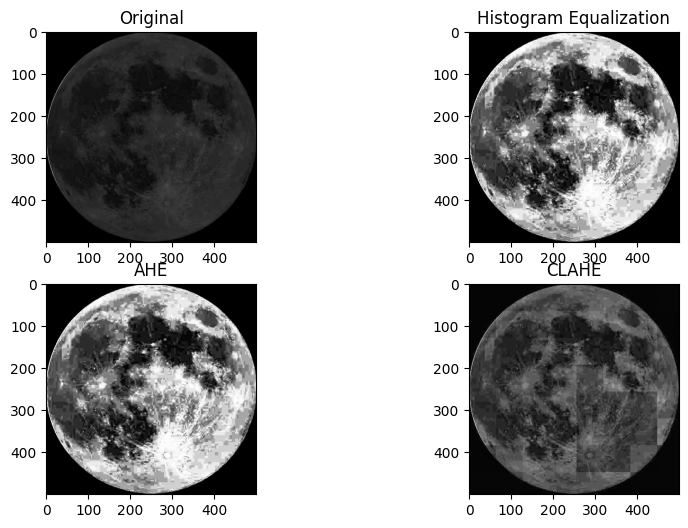

In [48]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(original_img, cmap='gray')

plt.subplot(2,2,2)
plt.title("Histogram Equalization")
plt.imshow(he_image, cmap='gray')

plt.subplot(2,2,3)
plt.title("AHE")
plt.imshow(ahe_image, cmap='gray')

plt.subplot(2,2,4)
plt.title("CLAHE")
plt.imshow(clahe_image, cmap='gray')

plt.show()

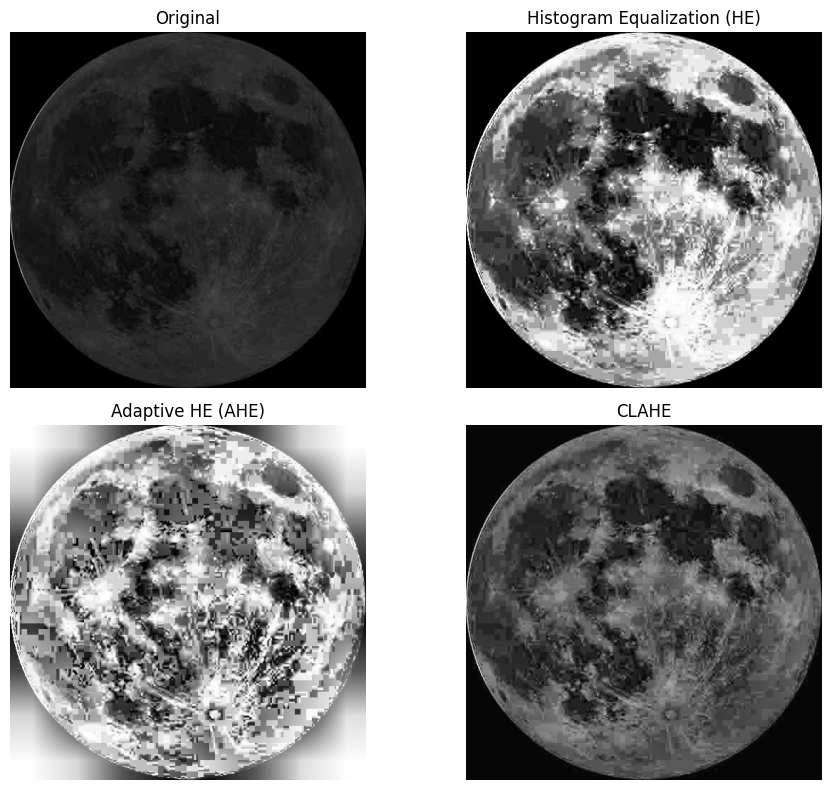

In [32]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("original_image.png", cv2.IMREAD_GRAYSCALE)

he = cv2.equalizeHist(img)

ahe = cv2.createCLAHE(clipLimit=255.0, tileGridSize=(8,8)) # limit = max value 로 설정
ahe_img = ahe.apply(img)

clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("Histogram Equalization (HE)")
plt.imshow(he, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("Adaptive HE (AHE)")
plt.imshow(ahe_img, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("CLAHE")
plt.imshow(clahe_img, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()